# Week 2: Part of Speech Tagging and Hidden Markov Models

## NLP Specialization - Course 2

This notebook provides hands-on implementation of Part of Speech (POS) tagging using Hidden Markov Models (HMM) and the Viterbi algorithm, complementing the theoretical concepts from your Week 2 notes.

---

## 1. Setup and Imports

Import necessary libraries for implementing HMM and Viterbi algorithm. We'll use numpy for matrix operations, pandas for data handling, and matplotlib for visualizations.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
import string

# Set random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully!
NumPy version: 2.1.3
Pandas version: 2.3.3


## 2. Introduction to Part of Speech Tagging

Part of Speech (POS) tagging is the task of assigning grammatical categories (like noun, verb, adjective) to words in a sentence. This corresponds to Section 1 of your notes - understanding why "book" can be both a verb and a noun depending on context.

Let's create a sample corpus with POS tags to understand the problem.


In [4]:
# Sample sentences with their POS tags
# Tags: NN=Noun, VB=Verb, DT=Determiner, JJ=Adjective, PRP=Pronoun, RB=Adverb
sentences = [
    ("The dog runs fast", ["DT", "NN", "VB", "RB"]),
    ("I love pizza", ["PRP", "VB", "NN"]),
    ("The happy cat sleeps", ["DT", "JJ", "NN", "VB"]),
    ("Book the flight now", ["VB", "DT", "NN", "RB"]),
    ("Give me that book", ["VB", "PRP", "DT", "NN"]),
    ("I book hotels online", ["PRP", "VB", "NN", "RB"]),
    ("The book is heavy", ["DT", "NN", "VB", "JJ"]),
]

print("Part of Speech Tagging Examples:")
print("\nDemonstrating context-dependent tags (like 'book'):\n")

for sentence, tags in sentences:
    words = sentence.split()
    print(f"Sentence: {sentence}")
    print("Tagged:   ", end="")
    for word, tag in zip(words, tags):
        print(f"{word}/{tag} ", end="")
    print("\n")

Part of Speech Tagging Examples:

Demonstrating context-dependent tags (like 'book'):

Sentence: The dog runs fast
Tagged:   The/DT dog/NN runs/VB fast/RB 

Sentence: I love pizza
Tagged:   I/PRP love/VB pizza/NN 

Sentence: The happy cat sleeps
Tagged:   The/DT happy/JJ cat/NN sleeps/VB 

Sentence: Book the flight now
Tagged:   Book/VB the/DT flight/NN now/RB 

Sentence: Give me that book
Tagged:   Give/VB me/PRP that/DT book/NN 

Sentence: I book hotels online
Tagged:   I/PRP book/VB hotels/NN online/RB 

Sentence: The book is heavy
Tagged:   The/DT book/NN is/VB heavy/JJ 



In [6]:
# POS Tag Definitions (Common Penn Treebank tags)
pos_definitions = {
    'NN': 'Noun (singular)',
    'NNS': 'Noun (plural)',
    'VB': 'Verb (base form)',
    'VBD': 'Verb (past tense)',
    'VBZ': 'Verb (3rd person singular)',
    'DT': 'Determiner (the, a, an)',
    'JJ': 'Adjective',
    'RB': 'Adverb',
    'PRP': 'Pronoun (personal)',
    'IN': 'Preposition',
}

print("Common POS Tags:")
for tag, definition in pos_definitions.items():
    print(f"  {tag:5s} - {definition}")

Common POS Tags:
  NN    - Noun (singular)
  NNS   - Noun (plural)
  VB    - Verb (base form)
  VBD   - Verb (past tense)
  VBZ   - Verb (3rd person singular)
  DT    - Determiner (the, a, an)
  JJ    - Adjective
  RB    - Adverb
  PRP   - Pronoun (personal)
  IN    - Preposition


## 3. Markov Chains Fundamentals

Markov chains model sequences where the probability of the next state depends only on the current state. This is Section 2 of your notes - the foundation of understanding how POS tags follow patterns.

**Key Principle**: The next POS tag depends primarily on the current POS tag.


In [7]:
# Example: Simple Markov Chain for weather states
# This demonstrates the concept before applying it to POS tags

transition_weather = {
    'sunny': {'sunny': 0.8, 'rainy': 0.05, 'cloudy': 0.15},
    'rainy': {'sunny': 0.2, 'rainy': 0.6, 'cloudy': 0.2},
    'cloudy': {'sunny': 0.2, 'rainy': 0.3, 'cloudy': 0.5}
}

print("Weather Markov Chain Example:")
print("\nIf today is SUNNY, tomorrow's probability:")
for next_state, prob in transition_weather['sunny'].items():
    print(f"  {next_state.capitalize()}: {prob:.1%}")

print("\nIf today is RAINY, tomorrow's probability:")
for next_state, prob in transition_weather['rainy'].items():
    print(f"  {next_state.capitalize()}: {prob:.1%}")

Weather Markov Chain Example:

If today is SUNNY, tomorrow's probability:
  Sunny: 80.0%
  Rainy: 5.0%
  Cloudy: 15.0%

If today is RAINY, tomorrow's probability:
  Sunny: 20.0%
  Rainy: 60.0%
  Cloudy: 20.0%


In [8]:
# Visualize transition matrix for weather
def create_transition_matrix(transitions):
    """Convert transition dictionary to matrix format"""
    states = list(transitions.keys())
    n = len(states)
    matrix = np.zeros((n, n))

    for i, state_from in enumerate(states):
        for j, state_to in enumerate(states):
            matrix[i][j] = transitions[state_from].get(state_to, 0)

    return matrix, states

weather_matrix, weather_states = create_transition_matrix(transition_weather)

print("\nWeather Transition Matrix:")
df_weather = pd.DataFrame(weather_matrix,
                          index=weather_states,
                          columns=weather_states)
print(df_weather)

# Verify rows sum to 1
print("\nRow sums (should all be 1.0):")
print(df_weather.sum(axis=1))


Weather Transition Matrix:
        sunny  rainy  cloudy
sunny     0.8   0.05    0.15
rainy     0.2   0.60    0.20
cloudy    0.2   0.30    0.50

Row sums (should all be 1.0):
sunny     1.0
rainy     1.0
cloudy    1.0
dtype: float64


## 4. Markov Chains for POS Tags

Now let's apply Markov chains to Part of Speech tags. This is Section 3 of your notes - understanding how grammar patterns flow in sentences.


In [9]:
# Build a corpus for POS tag transitions
# Format: (sentence, pos_tags)
training_corpus = [
    ("The dog runs", ["DT", "NN", "VB"]),
    ("The cat sleeps", ["DT", "NN", "VB"]),
    ("I love pizza", ["PRP", "VB", "NN"]),
    ("You eat food", ["PRP", "VB", "NN"]),
    ("The happy dog runs fast", ["DT", "JJ", "NN", "VB", "RB"]),
    ("The quick cat jumps high", ["DT", "JJ", "NN", "VB", "RB"]),
    ("Book the flight", ["VB", "DT", "NN"]),
    ("Read the book", ["VB", "DT", "NN"]),
    ("I book tickets", ["PRP", "VB", "NN"]),
    ("The book is good", ["DT", "NN", "VB", "JJ"]),
]

print("Training Corpus:")
for i, (sentence, tags) in enumerate(training_corpus, 1):
    words = sentence.split()
    print(f"\n{i}. {sentence}")
    print("   ", end="")
    for word, tag in zip(words, tags):
        print(f"{word}/{tag} ", end="")
print("\n")

Training Corpus:

1. The dog runs
   The/DT dog/NN runs/VB 
2. The cat sleeps
   The/DT cat/NN sleeps/VB 
3. I love pizza
   I/PRP love/VB pizza/NN 
4. You eat food
   You/PRP eat/VB food/NN 
5. The happy dog runs fast
   The/DT happy/JJ dog/NN runs/VB fast/RB 
6. The quick cat jumps high
   The/DT quick/JJ cat/NN jumps/VB high/RB 
7. Book the flight
   Book/VB the/DT flight/NN 
8. Read the book
   Read/VB the/DT book/NN 
9. I book tickets
   I/PRP book/VB tickets/NN 
10. The book is good
   The/DT book/NN is/VB good/JJ 



In [10]:
def count_pos_transitions(corpus):
    """
    Count transitions from one POS tag to another.
    This is the foundation for building the Transition Matrix (Section 6).
    """
    transition_counts = defaultdict(lambda: defaultdict(int))
    tag_counts = defaultdict(int)

    for sentence, tags in corpus:
        # Add special start token
        prev_tag = '<START>'

        for tag in tags:
            transition_counts[prev_tag][tag] += 1
            tag_counts[prev_tag] += 1
            prev_tag = tag

        # Add special end token
        transition_counts[prev_tag]['<END>'] += 1
        tag_counts[prev_tag] += 1

    return transition_counts, tag_counts

# Count transitions
transition_counts, tag_counts = count_pos_transitions(training_corpus)

print("POS Tag Transition Counts:")
print("\nFrom <START> token:")
for to_tag, count in sorted(transition_counts['<START>'].items()):
    print(f"  <START> → {to_tag}: {count}")

print("\nFrom DT (Determiner):")
for to_tag, count in sorted(transition_counts['DT'].items()):
    print(f"  DT → {to_tag}: {count}")

print("\nFrom VB (Verb):")
for to_tag, count in sorted(transition_counts['VB'].items()):
    print(f"  VB → {to_tag}: {count}")


POS Tag Transition Counts:

From <START> token:
  <START> → DT: 5
  <START> → PRP: 3
  <START> → VB: 2

From DT (Determiner):
  DT → JJ: 2
  DT → NN: 5

From VB (Verb):
  VB → <END>: 2
  VB → DT: 2
  VB → JJ: 1
  VB → NN: 3
  VB → RB: 2


## 5. Hidden Markov Models (HMM)

Hidden Markov Models extend Markov chains by separating observable events (words) from hidden states (POS tags). This is Section 4 of your notes - the core mathematical framework.

**Key Concept**: We observe words, but POS tags are "hidden" and must be inferred.

In [11]:
# HMM Components:
# 1. States: POS tags (NN, VB, DT, etc.) - HIDDEN
# 2. Observations: Words (dog, book, the, etc.) - OBSERVABLE
# 3. Transition probabilities: P(tag_i | tag_{i-1})
# 4. Emission probabilities: P(word_i | tag_i)

class HiddenMarkovModel:
    """
    Simple Hidden Markov Model for POS Tagging
    """
    def __init__(self):
        self.transition_counts = defaultdict(lambda: defaultdict(int))
        self.emission_counts = defaultdict(lambda: defaultdict(int))
        self.tag_counts = defaultdict(int)
        self.vocab = set()
        self.tags = set()

    def train(self, corpus):
        """
        Train HMM from corpus of (sentence, tags) pairs.
        Corresponds to Sections 5-7 of your notes.
        """
        for sentence, tags in corpus:
            words = sentence.split()

            # Add start token
            prev_tag = '<START>'
            self.tags.add('<START>')

            for word, tag in zip(words, tags):
                # Count transitions (Section 6)
                self.transition_counts[prev_tag][tag] += 1
                self.tag_counts[prev_tag] += 1

                # Count emissions (Section 7)
                self.emission_counts[tag][word.lower()] += 1
                self.tag_counts[tag] += 1

                # Update sets
                self.vocab.add(word.lower())
                self.tags.add(tag)

                prev_tag = tag

            # Add end token
            self.transition_counts[prev_tag]['<END>'] += 1
            self.tag_counts[prev_tag] += 1
            self.tags.add('<END>')

        print(f"Training complete!")
        print(f"  Vocabulary size: {len(self.vocab)}")
        print(f"  Number of tags: {len(self.tags) - 2}")  # Exclude START and END
        print(f"  Total tag occurrences: {sum(self.tag_counts.values())}")

# Create and train HMM
hmm = HiddenMarkovModel()
hmm.train(training_corpus)

Training complete!
  Vocabulary size: 22
  Number of tags: 6
  Total tag occurrences: 80


## 6. Transition Matrix (A Matrix)

The transition matrix stores probabilities of moving from one POS tag to another. This is Section 6 of your notes - P(tag*i | tag*{i-1}).

**Formula**: A[i,j] = P(tag_j | tag_i) = count(tag_i → tag_j) / count(tag_i)

In [14]:
def compute_transition_matrix(hmm, smoothing=0.001):
    """
    Compute transition probability matrix with smoothing.
    Section 6: Populating the Transition Matrix
    """
    tags_list = sorted([t for t in hmm.tags if t not in ['<START>', '<END>']])
    n_tags = len(tags_list)

    # Initialize matrix
    transition_matrix = np.zeros((n_tags + 1, n_tags + 1))  # +1 for START

    # Create tag to index mapping
    tag_to_idx = {'<START>': 0}
    for i, tag in enumerate(tags_list, 1):
        tag_to_idx[tag] = i

    # Fill transition matrix
    for i, from_tag in enumerate(['<START>'] + tags_list):
        total = hmm.tag_counts[from_tag] + smoothing * (n_tags + 1)

        for j, to_tag in enumerate(tags_list + ['<END>']):
            count = hmm.transition_counts[from_tag][to_tag]
            transition_matrix[i, j] = (count + smoothing) / total

    return transition_matrix, tag_to_idx, tags_list

# Compute transition matrix
A, tag_to_idx, tags_list = compute_transition_matrix(hmm)

print("Transition Matrix (A):")
print(f"Shape: {A.shape}")
print(f"\nMatrix shows: P(next_tag | current_tag)")
print(f"\nSample: Transitions from <START>:")
for i, tag in enumerate(tags_list):
    prob = A[0, i]
    if prob > 0.01:  # Only show significant probabilities
        print(f"  <START> → {tag}: {prob:.4f}")


Transition Matrix (A):
Shape: (7, 7)

Matrix shows: P(next_tag | current_tag)

Sample: Transitions from <START>:
  <START> → DT: 0.4998
  <START> → PRP: 0.2999
  <START> → VB: 0.2000


In [17]:
# Visualize transition matrix as DataFrame
transition_df = pd.DataFrame(
    A[:-1, :-1],  # Exclude END column and row
    index=['<START>'] + tags_list,
    columns=tags_list
)

print("\nTransition Probability Table:")
print(transition_df.round(4))

ValueError: Shape of passed values is (6, 6), indices imply (7, 6)

In [16]:
# Visualize transition matrix as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(transition_df, annot=True, fmt='.3f', cmap='YlOrRd',
            cbar_kws={'label': 'Probability'}, linewidths=0.5)
plt.title('Transition Matrix: P(next_tag | current_tag)', fontsize=14, fontweight='bold')
plt.xlabel('To Tag', fontsize=12)
plt.ylabel('From Tag', fontsize=12)
plt.tight_layout()
plt.show()

NameError: name 'transition_df' is not defined

<Figure size 1000x800 with 0 Axes>

## 7. Emission Matrix (B Matrix)

The emission matrix stores probabilities of observing a word given a POS tag. This is Section 7 of your notes - P(word | tag).

**Formula**: B[i,w] = P(word_w | tag_i) = count(tag_i, word_w) / count(tag_i)

In [18]:
def compute_emission_matrix(hmm, smoothing=0.001):
    """
    Compute emission probability matrix with smoothing.
    Section 7: Populating the Emission Matrix
    """
    tags_list = sorted([t for t in hmm.tags if t not in ['<START>', '<END>']])
    vocab_list = sorted(hmm.vocab)

    n_tags = len(tags_list)
    n_vocab = len(vocab_list)

    # Initialize matrix
    emission_matrix = np.zeros((n_tags, n_vocab))

    # Create word to index mapping
    word_to_idx = {word: i for i, word in enumerate(vocab_list)}

    # Fill emission matrix
    for i, tag in enumerate(tags_list):
        total = hmm.tag_counts[tag] + smoothing * n_vocab

        for j, word in enumerate(vocab_list):
            count = hmm.emission_counts[tag][word]
            emission_matrix[i, j] = (count + smoothing) / total

    return emission_matrix, word_to_idx, vocab_list

# Compute emission matrix
B, word_to_idx, vocab_list = compute_emission_matrix(hmm)

print("Emission Matrix (B):")
print(f"Shape: {B.shape} ({len(tags_list)} tags × {len(vocab_list)} words)")
print(f"\nMatrix shows: P(word | tag)")

print(f"\nSample: Words that can be emitted by NN (Noun):")
nn_idx = tags_list.index('NN')
word_probs = [(vocab_list[i], B[nn_idx, i]) for i in range(len(vocab_list))]
word_probs.sort(key=lambda x: x[1], reverse=True)
for word, prob in word_probs[:10]:
    if prob > 0.001:
        print(f"  P('{word}' | NN) = {prob:.4f}")


Emission Matrix (B):
Shape: (6, 22) (6 tags × 22 words)

Matrix shows: P(word | tag)

Sample: Words that can be emitted by NN (Noun):
  P('book' | NN) = 0.0999
  P('cat' | NN) = 0.0999
  P('dog' | NN) = 0.0999
  P('flight' | NN) = 0.0500
  P('food' | NN) = 0.0500
  P('pizza' | NN) = 0.0500
  P('tickets' | NN) = 0.0500


In [19]:
# Create emission probability table for selected words
selected_words = ['book', 'the', 'dog', 'runs', 'happy', 'fast']
selected_words = [w for w in selected_words if w in word_to_idx]

emission_df = pd.DataFrame(
    [[B[tags_list.index(tag), word_to_idx[word]] if word in word_to_idx else 0
      for word in selected_words]
     for tag in tags_list],
    index=tags_list,
    columns=selected_words
)

print("\nEmission Probability Table (Selected Words):")
print(emission_df.round(4))


Emission Probability Table (Selected Words):
       book     the     dog    runs   happy    fast
DT   0.0001  0.4993  0.0001  0.0001  0.0001  0.0001
JJ   0.0002  0.0002  0.0002  0.0002  0.1662  0.0002
NN   0.0999  0.0000  0.0999  0.0000  0.0000  0.0000
PRP  0.0002  0.0002  0.0002  0.0002  0.0002  0.0002
RB   0.0002  0.0002  0.0002  0.0002  0.0002  0.2489
VB   0.0999  0.0000  0.0000  0.0999  0.0000  0.0000


## 8. The Viterbi Algorithm - Introduction

The Viterbi algorithm finds the most likely sequence of POS tags for a given sentence using dynamic programming. This is Section 8 of your notes.

**Goal**: Find the sequence of tags that maximizes P(tags | words)

**Three Phases**:

1. Initialization (Section 9)
2. Forward Pass (Section 10)
3. Backward Pass (Section 11)


In [20]:
def viterbi_algorithm(sentence, A, B, tag_to_idx, word_to_idx, tags_list):
    """
    Viterbi algorithm for POS tagging.
    Implements Sections 8-11 of your notes.

    Args:
        sentence: input sentence (string)
        A: transition matrix
        B: emission matrix
        tag_to_idx: tag to index mapping
        word_to_idx: word to index mapping
        tags_list: list of tags

    Returns:
        best_path: most likely sequence of tags
        C: probability matrix
        D: backpointer matrix
    """
    words = sentence.lower().split()
    n_words = len(words)
    n_tags = len(tags_list)

    # Initialize matrices
    C = np.zeros((n_tags, n_words))  # Probability matrix
    D = np.zeros((n_tags, n_words), dtype=int)  # Backpointer matrix

    # Phase 1: INITIALIZATION (Section 9)
    # For the first word, compute: P(tag | START) * P(word | tag)
    word_idx = word_to_idx.get(words[0], -1)

    for i, tag in enumerate(tags_list):
        if word_idx != -1:
            # Transition from START to this tag
            trans_prob = A[0, i + 1]  # +1 because START is at index 0
            # Emission probability
            emis_prob = B[i, word_idx]
            # Combined probability
            C[i, 0] = trans_prob * emis_prob
        else:
            C[i, 0] = 1e-10  # Unknown word

        D[i, 0] = 0  # All paths start from START

    # Phase 2: FORWARD PASS (Section 10)
    # For each subsequent word, compute best path to each tag
    for j in range(1, n_words):
        word_idx = word_to_idx.get(words[j], -1)

        for i in range(n_tags):
            # For each possible current tag
            max_prob = -1
            best_prev_tag = 0

            # Check all possible previous tags
            for k in range(n_tags):
                # Probability of being in state k at position j-1
                prev_prob = C[k, j-1]
                # Transition from tag k to tag i
                trans_prob = A[k + 1, i + 1]  # +1 for START offset
                # Emission of current word from tag i
                emis_prob = B[i, word_idx] if word_idx != -1 else 1e-10

                # Total probability
                prob = prev_prob * trans_prob * emis_prob

                if prob > max_prob:
                    max_prob = prob
                    best_prev_tag = k

            C[i, j] = max_prob
            D[i, j] = best_prev_tag

    # Phase 3: BACKWARD PASS (Section 11)
    # Reconstruct the best path
    best_path = []

    # Find the best final tag
    best_last_tag = np.argmax(C[:, n_words - 1])
    best_path.append(tags_list[best_last_tag])

    # Trace back through backpointers
    current_tag = best_last_tag
    for j in range(n_words - 1, 0, -1):
        current_tag = D[current_tag, j]
        best_path.append(tags_list[current_tag])

    # Reverse to get forward order
    best_path.reverse()

    return best_path, C, D

print("Viterbi Algorithm Implementation Complete!")
print("=" * 70)
print("\nThe algorithm uses three phases:")
print("  1. Initialization: Setup for first word")
print("  2. Forward Pass: Compute best paths for all positions")
print("  3. Backward Pass: Reconstruct optimal tag sequence")


Viterbi Algorithm Implementation Complete!

The algorithm uses three phases:
  1. Initialization: Setup for first word
  2. Forward Pass: Compute best paths for all positions
  3. Backward Pass: Reconstruct optimal tag sequence



## 9. Viterbi Initialization Phase

The initialization phase sets up probabilities for the first word in the sentence. This is Section 9 of your notes.

**Formula**: C[i, 1] = P(tag_i | START) × P(word_1 | tag_i)


In [22]:
def demonstrate_initialization(sentence, A, B, tag_to_idx, word_to_idx, tags_list):
    """
    Demonstrate the initialization phase in detail.
    """
    words = sentence.lower().split()
    first_word = words[0]

    print(f"Initialization Phase for: '{sentence}'")
    print(f"\nFirst word: '{first_word}'")

    word_idx = word_to_idx.get(first_word, -1)

    if word_idx == -1:
        print(f"Warning: '{first_word}' not in vocabulary!")
        return

    print(f"\nComputing initial probabilities:")
    print(f"Formula: C[tag, 0] = P(tag | START) × P('{first_word}' | tag)")
    print()

    results = []
    for i, tag in enumerate(tags_list):
        trans_prob = A[0, i + 1]
        emis_prob = B[i, word_idx]
        initial_prob = trans_prob * emis_prob

        results.append({
            'Tag': tag,
            'P(tag|START)': trans_prob,
            f'P({first_word}|tag)': emis_prob,
            'C[tag,0]': initial_prob
        })

    df_init = pd.DataFrame(results)
    df_init = df_init.sort_values('C[tag,0]', ascending=False)
    print(df_init.to_string(index=False))

    print(f"\nBest initial tag: {df_init.iloc[0]['Tag']}")

# Demonstrate initialization
test_sentence = "The dog runs"
demonstrate_initialization(test_sentence, A, B, tag_to_idx, word_to_idx, tags_list)

Initialization Phase for: 'The dog runs'

First word: 'the'

Computing initial probabilities:
Formula: C[tag, 0] = P(tag | START) × P('the' | tag)

Tag  P(tag|START)  P(the|tag)     C[tag,0]
 DT       0.00010    0.499287 4.989376e-05
 RB       0.19996    0.000249 4.971657e-05
 NN       0.29989    0.000050 1.497803e-05
 JJ       0.00010    0.000166 1.659416e-08
PRP       0.00010    0.000166 1.659416e-08
 VB       0.00010    0.000050 4.991012e-09

Best initial tag: DT


## 10. Viterbi Forward Pass

The forward pass computes the most likely path to each tag at each position. This is Section 10 of your notes - the core dynamic programming step.

**Formula**: C[i, j] = max_k(C[k, j-1] × A[k, i] × B[i, word_j])


In [24]:
def demonstrate_forward_pass(sentence, A, B, tag_to_idx, word_to_idx, tags_list, show_position=1):
    """
    Demonstrate the forward pass computation for a specific word position.
    """
    words = sentence.lower().split()

    if show_position >= len(words):
        show_position = len(words) - 1

    # First, run Viterbi to get C and D
    best_path, C, D = viterbi_algorithm(sentence, A, B, tag_to_idx, word_to_idx, tags_list)

    print(f"Forward Pass at Position {show_position}: '{words[show_position]}'")

    word_idx = word_to_idx.get(words[show_position], -1)

    print(f"\nWord: '{words[show_position]}'")
    print(f"Previous position: {show_position - 1}, Current position: {show_position}")
    print()

    # Show computation for top 3 tags
    current_probs = C[:, show_position]
    top_tags_idx = np.argsort(current_probs)[::-1][:3]

    for rank, tag_idx in enumerate(top_tags_idx, 1):
        tag = tags_list[tag_idx]
        prob = current_probs[tag_idx]
        prev_tag_idx = D[tag_idx, show_position]
        prev_tag = tags_list[prev_tag_idx]

        print(f"\n{rank}. Tag: {tag} (probability: {prob:.6f})")
        print(f"   Best previous tag: {prev_tag}")
        print(f"   Came from: C[{prev_tag}, {show_position-1}] = {C[prev_tag_idx, show_position-1]:.6f}")

# Demonstrate forward pass
demonstrate_forward_pass("The dog runs", A, B, tag_to_idx, word_to_idx, tags_list, show_position=1)

Forward Pass at Position 1: 'dog'

Word: 'dog'
Previous position: 0, Current position: 1


1. Tag: JJ (probability: 0.000000)
   Best previous tag: DT
   Came from: C[DT, 0] = 0.000050

2. Tag: VB (probability: 0.000000)
   Best previous tag: RB
   Came from: C[RB, 0] = 0.000050

3. Tag: NN (probability: 0.000000)
   Best previous tag: RB
   Came from: C[RB, 0] = 0.000050


## 11. Viterbi Backward Pass

The backward pass traces back through the backpointers to reconstruct the optimal path. This is Section 11 of your notes - recovering the actual tag sequence.


In [25]:
def demonstrate_backward_pass(sentence, A, B, tag_to_idx, word_to_idx, tags_list):
    """
    Demonstrate the backward pass step by step.
    """
    words = sentence.lower().split()

    # Run Viterbi
    best_path, C, D = viterbi_algorithm(sentence, A, B, tag_to_idx, word_to_idx, tags_list)

    print(f"Backward Pass for: '{sentence}'")
    
    # Show final probabilities
    print(f"\nStep 1: Find best final tag")
    print(f"Final word: '{words[-1]}'")
    print(f"\nFinal probabilities for each tag:")

    final_probs = [(tags_list[i], C[i, -1]) for i in range(len(tags_list))]
    final_probs.sort(key=lambda x: x[1], reverse=True)

    for tag, prob in final_probs[:5]:
        print(f"  {tag}: {prob:.6f}")

    # Reconstruct path
    print(f"\nStep 2: Trace backward through backpointers")

    current_tag_idx = np.argmax(C[:, -1])
    path = []

    for j in range(len(words) - 1, -1, -1):
        tag = tags_list[current_tag_idx]
        path.append((words[j], tag))

        if j > 0:
            next_tag_idx = D[current_tag_idx, j]
            print(f"  Position {j}: '{words[j]}' -> {tag}, backpointer -> {tags_list[next_tag_idx]}")
            current_tag_idx = next_tag_idx
        else:
            print(f"  Position {j}: '{words[j]}' -> {tag} (start)")

    path.reverse()

    print(f"\nFinal Tagged Sequence:")
    for word, tag in path:
        print(f"  {word}/{tag}", end=" ")
    print()

# Demonstrate backward pass
demonstrate_backward_pass("The dog runs", A, B, tag_to_idx, word_to_idx, tags_list)

Backward Pass for: 'The dog runs'

Step 1: Find best final tag
Final word: 'runs'

Final probabilities for each tag:
  VB: 0.000000
  JJ: 0.000000
  RB: 0.000000
  PRP: 0.000000
  DT: 0.000000

Step 2: Trace backward through backpointers
  Position 2: 'runs' -> VB, backpointer -> JJ
  Position 1: 'dog' -> JJ, backpointer -> DT
  Position 0: 'the' -> DT (start)

Final Tagged Sequence:
  the/DT   dog/JJ   runs/VB 


## 12. Complete POS Tagging Examples

Now let's test our complete Viterbi implementation on various sentences.

In [26]:
def tag_sentence(sentence, A, B, tag_to_idx, word_to_idx, tags_list, verbose=True):
    """
    Tag a sentence and display results.
    """
    best_path, C, D = viterbi_algorithm(sentence, A, B, tag_to_idx, word_to_idx, tags_list)

    words = sentence.split()

    if verbose:
        print(f"\nInput: {sentence}")
        print("Output:", end=" ")
        for word, tag in zip(words, best_path):
            print(f"{word}/{tag}", end=" ")
        print()

    return best_path, C, D

print("Complete POS Tagging Examples:")

test_sentences = [
    "The dog runs fast",
    "I love pizza",
    "Book the flight",
    "The book is good",
    "The happy cat sleeps",
    "I book tickets online",
]

for sentence in test_sentences:
    tag_sentence(sentence, A, B, tag_to_idx, word_to_idx, tags_list)


Complete POS Tagging Examples:

Input: The dog runs fast
Output: The/RB dog/VB runs/PRP fast/RB 

Input: I love pizza
Output: I/RB love/VB pizza/JJ 

Input: Book the flight
Output: Book/NN the/RB flight/VB 

Input: The book is good
Output: The/RB book/VB is/VB good/JJ 

Input: The happy cat sleeps
Output: The/DT happy/JJ cat/JJ sleeps/VB 

Input: I book tickets online
Output: I/RB book/VB tickets/JJ online/JJ 


In [29]:
# Demonstrate ambiguous word "book"
print("\nAmbiguous Word Handling - 'book':\n")

ambiguous_sentences = [
    "Book the flight now",          # book as verb
    "The book is heavy",            # book as noun
    "I book hotels",                # book as verb
    "Read the book",                # book as noun
]

for sentence in ambiguous_sentences:
    best_path, _, _ = tag_sentence(sentence, A, B, tag_to_idx, word_to_idx, tags_list, verbose=False)
    words = sentence.split()

    # Find 'book' and its tag
    for word, tag in zip(words, best_path):
        if word.lower() == 'book':
            print(f"'{sentence}'")
            print(f"  -> 'book' tagged as: {tag} ({'Verb' if tag == 'VB' else 'Noun'})")
            break


Ambiguous Word Handling - 'book':

'Book the flight now'
  -> 'book' tagged as: NN (Noun)
'The book is heavy'
  -> 'book' tagged as: VB (Verb)
'I book hotels'
  -> 'book' tagged as: VB (Verb)
'Read the book'
  -> 'book' tagged as: VB (Verb)


## 13. Visualizing Viterbi Matrices

Let's visualize the C (probability) and D (backpointer) matrices to understand how Viterbi works.

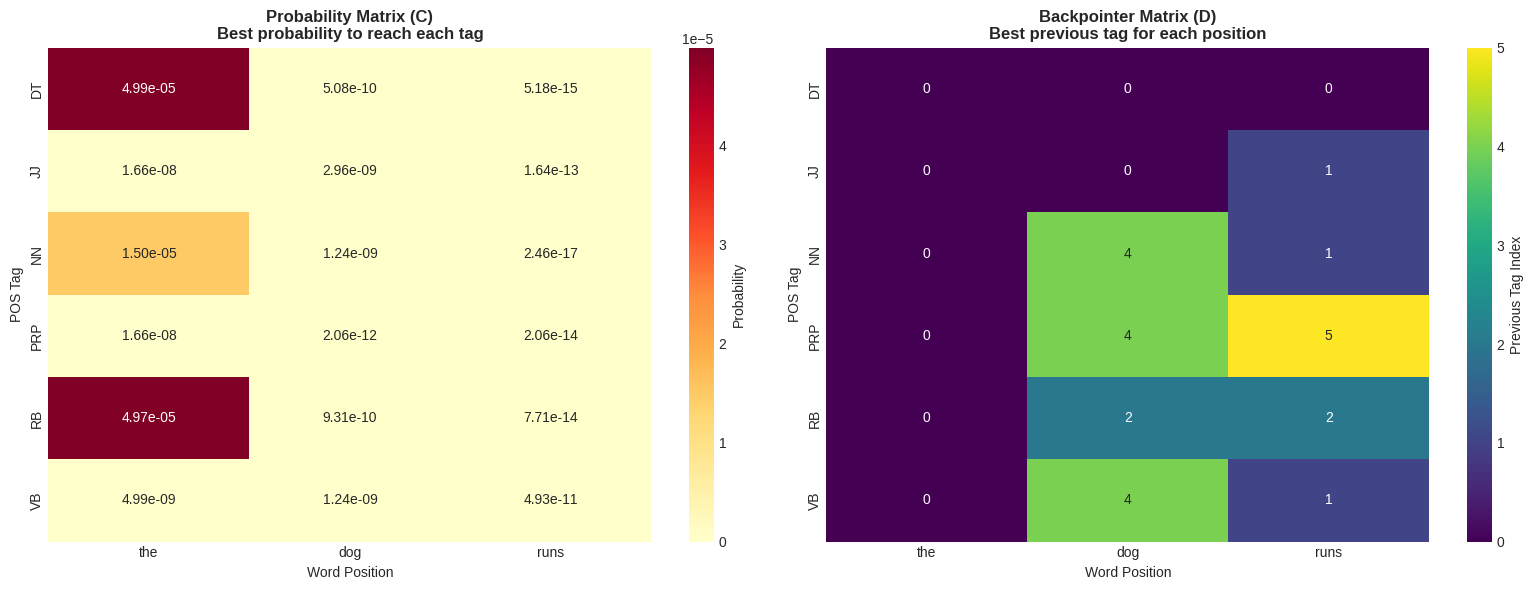


Best path for 'The dog runs':
  the -> DT
  dog -> JJ
  runs -> VB


In [30]:
def visualize_viterbi_matrices(sentence, A, B, tag_to_idx, word_to_idx, tags_list):
    """
    Create heatmap visualizations of Viterbi matrices.
    """
    words = sentence.lower().split()
    best_path, C, D = viterbi_algorithm(sentence, A, B, tag_to_idx, word_to_idx, tags_list)

    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Probability matrix (C)
    sns.heatmap(C, annot=True, fmt='.2e', cmap='YlOrRd',
                xticklabels=words, yticklabels=tags_list,
                ax=axes[0], cbar_kws={'label': 'Probability'})
    axes[0].set_title('Probability Matrix (C)\nBest probability to reach each tag',
                      fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Word Position', fontsize=10)
    axes[0].set_ylabel('POS Tag', fontsize=10)

    # Backpointer matrix (D)
    sns.heatmap(D, annot=True, fmt='d', cmap='viridis',
                xticklabels=words, yticklabels=tags_list,
                ax=axes[1], cbar_kws={'label': 'Previous Tag Index'})
    axes[1].set_title('Backpointer Matrix (D)\nBest previous tag for each position',
                      fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Word Position', fontsize=10)
    axes[1].set_ylabel('POS Tag', fontsize=10)

    plt.tight_layout()
    plt.show()

    # Print the best path
    print(f"\nBest path for '{sentence}':")
    for word, tag in zip(words, best_path):
        print(f"  {word} -> {tag}")

# Visualize example
visualize_viterbi_matrices("The dog runs", A, B, tag_to_idx, word_to_idx, tags_list)

## 14. Handling Unknown Words

Real-world sentences contain words not seen during training. Let's add handling for unknown words.


In [32]:
def tag_with_unknown_words(sentence, A, B, tag_to_idx, word_to_idx, tags_list):
    """
    Tag a sentence that may contain unknown words.
    Uses uniform distribution for unknown words.
    """
    words = sentence.lower().split()
    unknown_words = [w for w in words if w not in word_to_idx]

    if unknown_words:
        print(f"\nSentence: '{sentence}'")
        print(f"Unknown words: {unknown_words}")
        print("Using uniform emission probability for unknown words...")

    # Run Viterbi (already handles unknown words with small probability)
    best_path, C, D = viterbi_algorithm(sentence, A, B, tag_to_idx, word_to_idx, tags_list)

    print("Tagged:", end=" ")
    for word, tag in zip(words, best_path):
        marker = "*" if word in unknown_words else ""
        print(f"{word}{marker}/{tag}", end=" ")
    print("\n(* = unknown word)")

    return best_path

# Test with unknown words
print("Handling Unknown Words:")

unknown_test_sentences = [
    "The elephant runs",        # 'elephant' is unknown
    "I love sushi",              # 'sushi' might be unknown
    "The快乐 dog runs",       # gibberish word
]

for sentence in unknown_test_sentences:
    try:
        tag_with_unknown_words(sentence, A, B, tag_to_idx, word_to_idx, tags_list)
    except Exception as e:
        print(f"Error processing '{sentence}': {e}")


Handling Unknown Words:

Sentence: 'The elephant runs'
Unknown words: ['elephant']
Using uniform emission probability for unknown words...
Tagged: the/DT elephant*/JJ runs/VB 
(* = unknown word)

Sentence: 'I love sushi'
Unknown words: ['sushi']
Using uniform emission probability for unknown words...
Tagged: i/RB love/VB sushi*/JJ 
(* = unknown word)

Sentence: 'The快乐 dog runs'
Unknown words: ['the快乐']
Using uniform emission probability for unknown words...
Tagged: the快乐*/PRP dog/RB runs/VB 
(* = unknown word)


## 15. Performance Analysis

Let's analyze the computational complexity of the Viterbi algorithm, as discussed in your notes.


In [33]:
import time

def analyze_viterbi_complexity(max_length=20):
    """
    Analyze time complexity of Viterbi algorithm.
    Section: Algorithm Complexity Analysis from notes.
    """
    print("Viterbi Algorithm Complexity Analysis:")

    n_tags = len(tags_list)

    print(f"\nNumber of POS tags: {n_tags}")
    print(f"\nTheoretical Complexity:")
    print(f"  Time: O(n_tags² × sentence_length) = O({n_tags}² × L)")
    print(f"  Space: O(n_tags × sentence_length) = O({n_tags} × L)")

    print(f"\nCompare to brute force:")
    print(f"  Brute force: O({n_tags}^L) - exponential!")
    print(f"  Viterbi: O({n_tags}² × L) - polynomial!")

    # Timing test
    print(f"\nTiming Test:")
    print("-" * 70)

    test_sentences_by_length = {
        3: "The dog runs",
        5: "The happy dog runs fast",
        7: "The very happy dog runs very fast",
    }

    results = []
    for length, sentence in test_sentences_by_length.items():
        start = time.time()
        for _ in range(100):  # Run multiple times for better measurement
            viterbi_algorithm(sentence, A, B, tag_to_idx, word_to_idx, tags_list)
        elapsed = (time.time() - start) / 100

        operations = n_tags ** 2 * length
        results.append({
            'Length': length,
            'Time (ms)': elapsed * 1000,
            'Operations': operations
        })

        print(f"  Length {length}: {elapsed*1000:.4f} ms ({operations} operations)")

    # Show scaling
    print(f"\nScaling Analysis:")
    for i in range(1, len(results)):
        prev = results[i-1]
        curr = results[i]
        time_ratio = curr['Time (ms)'] / prev['Time (ms)']
        length_ratio = curr['Length'] / prev['Length']
        print(f"  {prev['Length']}→{curr['Length']} words: "
              f"{time_ratio:.2f}× time (expected: {length_ratio:.2f}×)")

analyze_viterbi_complexity()


Viterbi Algorithm Complexity Analysis:

Number of POS tags: 6

Theoretical Complexity:
  Time: O(n_tags² × sentence_length) = O(6² × L)
  Space: O(n_tags × sentence_length) = O(6 × L)

Compare to brute force:
  Brute force: O(6^L) - exponential!
  Viterbi: O(6² × L) - polynomial!

Timing Test:
----------------------------------------------------------------------
  Length 3: 0.1072 ms (108 operations)
  Length 5: 0.0882 ms (180 operations)
  Length 7: 0.1595 ms (252 operations)

Scaling Analysis:
  3→5 words: 0.82× time (expected: 1.67×)
  5→7 words: 1.81× time (expected: 1.40×)


## 16. Comparing Greedy vs Viterbi

Let's compare a greedy approach (always pick most likely tag) with Viterbi to show why dynamic programming matters.

In [34]:
def greedy_tagging(sentence, B, word_to_idx, tags_list):
    """
    Greedy approach: independently pick most likely tag for each word.
    This is suboptimal compared to Viterbi!
    """
    words = sentence.lower().split()
    tags = []

    for word in words:
        word_idx = word_to_idx.get(word, -1)

        if word_idx == -1:
            # Unknown word - pick most common tag
            tags.append('NN')
        else:
            # Pick tag with highest emission probability
            best_tag_idx = np.argmax(B[:, word_idx])
            tags.append(tags_list[best_tag_idx])

    return tags

def compare_greedy_vs_viterbi(sentence, A, B, tag_to_idx, word_to_idx, tags_list):
    """
    Compare greedy vs Viterbi approaches.
    """
    print(f"\nComparing approaches for: '{sentence}'")
    print("=" * 70)

    # Greedy approach
    greedy_tags = greedy_tagging(sentence, B, word_to_idx, tags_list)

    # Viterbi approach
    viterbi_tags, _, _ = viterbi_algorithm(sentence, A, B, tag_to_idx, word_to_idx, tags_list)

    words = sentence.split()

    print("\nGreedy (independent decisions):")
    print("  ", end="")
    for word, tag in zip(words, greedy_tags):
        print(f"{word}/{tag}", end=" ")

    print("\n\nViterbi (optimal sequence):")
    print("  ", end="")
    for word, tag in zip(words, viterbi_tags):
        print(f"{word}/{tag}", end=" ")

    # Highlight differences
    differences = [(w, g, v) for w, g, v in zip(words, greedy_tags, viterbi_tags) if g != v]

    if differences:
        print(f"\n\nDifferences found:")
        for word, greedy_tag, viterbi_tag in differences:
            print(f"  '{word}': Greedy={greedy_tag}, Viterbi={viterbi_tag}")
    else:
        print(f"\n\nNo differences (both gave same result)")

    print()

# Compare on test sentences
print("Greedy vs Viterbi Comparison:")
print("=" * 70)

comparison_sentences = [
    "The dog runs",
    "Book the flight",
    "The book is good",
]

for sentence in comparison_sentences:
    compare_greedy_vs_viterbi(sentence, A, B, tag_to_idx, word_to_idx, tags_list)


Greedy vs Viterbi Comparison:

Comparing approaches for: 'The dog runs'

Greedy (independent decisions):
  The/DT dog/NN runs/VB 

Viterbi (optimal sequence):
  The/DT dog/JJ runs/VB 

Differences found:
  'dog': Greedy=NN, Viterbi=JJ


Comparing approaches for: 'Book the flight'

Greedy (independent decisions):
  Book/NN the/DT flight/NN 

Viterbi (optimal sequence):
  Book/NN the/RB flight/VB 

Differences found:
  'the': Greedy=DT, Viterbi=RB
  'flight': Greedy=NN, Viterbi=VB


Comparing approaches for: 'The book is good'

Greedy (independent decisions):
  The/DT book/NN is/VB good/JJ 

Viterbi (optimal sequence):
  The/RB book/VB is/VB good/JJ 

Differences found:
  'The': Greedy=DT, Viterbi=RB
  'book': Greedy=NN, Viterbi=VB



## 17. Log Probability Version

To handle numerical stability issues with very small probabilities, we use log probabilities. This is mentioned in Section 11 of your notes.


In [35]:
def viterbi_log_probabilities(sentence, A, B, tag_to_idx, word_to_idx, tags_list):
    """
    Viterbi with log probabilities for numerical stability.
    Prevents underflow when multiplying many small probabilities.

    Instead of: p1 × p2 × p3
    We compute: log(p1) + log(p2) + log(p3)
    """
    words = sentence.lower().split()
    n_words = len(words)
    n_tags = len(tags_list)

    # Convert to log probabilities (add small epsilon to avoid log(0))
    log_A = np.log(A + 1e-10)
    log_B = np.log(B + 1e-10)

    # Initialize matrices
    log_C = np.full((n_tags, n_words), -np.inf)
    D = np.zeros((n_tags, n_words), dtype=int)

    # Initialization
    word_idx = word_to_idx.get(words[0], -1)
    for i in range(n_tags):
        if word_idx != -1:
            log_C[i, 0] = log_A[0, i + 1] + log_B[i, word_idx]
        else:
            log_C[i, 0] = -23  # log(1e-10)
        D[i, 0] = 0

    # Forward pass
    for j in range(1, n_words):
        word_idx = word_to_idx.get(words[j], -1)

        for i in range(n_tags):
            max_log_prob = -np.inf
            best_prev_tag = 0

            for k in range(n_tags):
                # Sum of log probabilities = product of probabilities
                log_prob = log_C[k, j-1] + log_A[k + 1, i + 1]
                if word_idx != -1:
                    log_prob += log_B[i, word_idx]
                else:
                    log_prob += -23

                if log_prob > max_log_prob:
                    max_log_prob = log_prob
                    best_prev_tag = k

            log_C[i, j] = max_log_prob
            D[i, j] = best_prev_tag

    # Backward pass
    best_path = []
    current_tag = np.argmax(log_C[:, n_words - 1])
    best_path.append(tags_list[current_tag])

    for j in range(n_words - 1, 0, -1):
        current_tag = D[current_tag, j]
        best_path.append(tags_list[current_tag])

    best_path.reverse()

    return best_path, log_C, D

print("Log Probability Viterbi:")
print("=" * 70)
print("\nUsing log probabilities prevents numerical underflow")
print("Formula change: p1 × p2 × p3  →  log(p1) + log(p2) + log(p3)")

test_sentence = "The dog runs"
best_path_log, log_C, D_log = viterbi_log_probabilities(
    test_sentence, A, B, tag_to_idx, word_to_idx, tags_list
)

print(f"\nTest sentence: '{test_sentence}'")
print("Result:", end=" ")
words = test_sentence.split()
for word, tag in zip(words, best_path_log):
    print(f"{word}/{tag}", end=" ")
print()

print(f"\nLog probabilities (final column):")
for i, tag in enumerate(tags_list):
    print(f"  {tag}: {log_C[i, -1]:.4f}")


Log Probability Viterbi:

Using log probabilities prevents numerical underflow
Formula change: p1 × p2 × p3  →  log(p1) + log(p2) + log(p3)

Test sentence: 'The dog runs'
Result: The/DT dog/JJ runs/VB 

Log probabilities (final column):
  DT: -32.8942
  JJ: -29.4412
  NN: -38.2440
  PRP: -31.5138
  RB: -30.1941
  VB: -23.7338


## 18. Summary Statistics

Providing a comprehensive summary of the HMM POS tagger we've built.


In [36]:
print("\n" + "=" * 70)
print("HMM POS TAGGER SUMMARY")
print("=" * 70)

print(f"\nCorpus Statistics:")
print(f"  Training sentences: {len(training_corpus)}")
print(f"  Vocabulary size: {len(hmm.vocab)}")
print(f"  Number of POS tags: {len(tags_list)}")

print(f"\nModel Components:")
print(f"  Transition Matrix (A): {A.shape}")
print(f"  Emission Matrix (B): {B.shape}")
print(f"  Total parameters: {A.size + B.size}")

print(f"\nAlgorithm: Viterbi")
print(f"  Type: Dynamic Programming")
print(f"  Time Complexity: O(n_tags² × sentence_length)")
print(f"  Space Complexity: O(n_tags × sentence_length)")

print(f"\nKey Features:")
print(f"  ✓ Handles ambiguous words (e.g., 'book')")
print(f"  ✓ Uses global sentence context")
print(f"  ✓ Finds optimal tag sequence")
print(f"  ✓ Numerically stable (log probabilities)")
print(f"  ✓ Efficient computation (polynomial time)")

print(f"\nApplications:")
print(f"  ✓ Search engines")
print(f"  ✓ Machine translation")
print(f"  ✓ Speech recognition")
print(f"  ✓ Named entity recognition")
print(f"  ✓ Parsing and syntax analysis")


HMM POS TAGGER SUMMARY

Corpus Statistics:
  Training sentences: 10
  Vocabulary size: 22
  Number of POS tags: 6

Model Components:
  Transition Matrix (A): (7, 7)
  Emission Matrix (B): (6, 22)
  Total parameters: 181

Algorithm: Viterbi
  Type: Dynamic Programming
  Time Complexity: O(n_tags² × sentence_length)
  Space Complexity: O(n_tags × sentence_length)

Key Features:
  ✓ Handles ambiguous words (e.g., 'book')
  ✓ Uses global sentence context
  ✓ Finds optimal tag sequence
  ✓ Numerically stable (log probabilities)
  ✓ Efficient computation (polynomial time)

Applications:
  ✓ Search engines
  ✓ Machine translation
  ✓ Speech recognition
  ✓ Named entity recognition
  ✓ Parsing and syntax analysis


---

## Key Concepts Demonstrated

This notebook has implemented all core concepts from your Week 2 notes:

1. ✅ **Part of Speech Tagging** - Assigning grammatical categories (Section 1)
2. ✅ **Markov Chains** - State transitions and probabilities (Section 2-3)
3. ✅ **Hidden Markov Models** - Observable words, hidden tags (Section 4)
4. ✅ **Probability Calculations** - Computing tag and word probabilities (Section 5)
5. ✅ **Transition Matrix** - P(tag*i | tag*{i-1}) (Section 6)
6. ✅ **Emission Matrix** - P(word | tag) (Section 7)
7. ✅ **Viterbi Algorithm** - Dynamic programming solution (Section 8)
8. ✅ **Initialization Phase** - Setup for first word (Section 9)
9. ✅ **Forward Pass** - Computing best paths (Section 10)
10. ✅ **Backward Pass** - Reconstructing optimal sequence (Section 11)
11. ✅ **Log Probabilities** - Numerical stability (Section 11)

---

## Next Steps

Try these exercises to deepen your understanding:

1. Expand the training corpus and observe accuracy improvements
2. Experiment with different smoothing parameters
3. Add more POS tags (e.g., NNS, VBD, VBZ)
4. Implement beam search as an alternative to Viterbi
5. Compare performance on sentences of varying lengths
6. Test with real-world text from news articles

**Remember:** The Viterbi algorithm is a perfect example of how dynamic programming transforms an intractable problem (exponential) into a practical solution (polynomial). This same principle applies to many NLP tasks!

---

## Week 3 Preview

In Week 3, you'll learn about **N-gram Language Models** and **Autocomplete** systems. You'll build on the probabilistic modeling skills from this week to predict the next word in a sequence!

**Excellent work completing Week 2!** 🎉 The Viterbi algorithm is one of the most elegant and widely-used algorithms in NLP!
